<a href="https://colab.research.google.com/github/awildt01/Credit-Scoring/blob/main/notebooks/7_LGD_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Der **Loss Given Default (LGD)** ist ein Schlüsselparameter im Kreditrisikomanagement, der angibt, wie viel ein Kreditgeber voraussichtlich verlieren wird, wenn ein Kreditnehmer ausfällt. Er wird typischerweise als Prozentsatz des ausstehenden Kreditbetrags zum Zeitpunkt des Ausfalls ausgedrückt (1 - Recovery Rate).

**Der Two-Step-Modellansatz** (oder Zweistufenmodell) ist eine gängige Methode zur Modellierung des LGD, insbesondere wenn ein erheblicher Anteil der ausgefallenen Kredite keine Rückgewinnung erfährt (d.h. die Recovery Rate 0% beträgt).

Dieser Ansatz unterteilt den Modellierungsprozess in zwei Schritte:

**Schritt 1: Modellierung der Wahrscheinlichkeit einer Null-Rückgewinnung (Probability of Zero Recovery - PZR)**

- **Ziel:** Vorhersagen, ob überhaupt eine Rückgewinnung stattfinden wird oder ob der gesamte ausstehende Betrag verloren geht (Recovery Rate = 0%).

- **Abhängige Variable:** Eine binäre Variable, wie die recovery_rate_0_1, die wir erstellt haben. Sie ist 1, wenn es eine positive Rückgewinnung gab, und 0, wenn die Rückgewinnung 0 war.

- **Modelltyp:** Typischerweise wird hier ein binäres Klassifikationsmodell verwendet, wie eine logistische Regression oder ein Entscheidungsbaum. Dieses Modell schätzt die Wahrscheinlichkeit, dass ein ausgefallener Kredit eine Rückgewinnung von Null haben wird.

**Schritt 2: Modellierung der Rückgewinnungshöhe (Conditional Recovery Rate)**

- **Ziel:** Für die Fälle, in denen eine Rückgewinnung erwartet wird (d.h. das Modell aus Schritt 1 hat eine positive Rückgewinnung vorhergesagt), wird die tatsächliche Höhe der Recovery Rate modelliert.

- **Abhängige Variable:** Die recovery_rate selbst, aber nur für die Fälle, in denen sie größer als 0 ist (oder allgemeiner, zwischen 0 und 1 liegt, exklusive 0).

- **Modelltyp:** Hier kommen in der Regel Regressionsmodelle zum Einsatz, wie zum Beispiel die lineare Regression, Beta-Regression oder TOBIT-Modelle (die zensierte Daten berücksichtigen können, da die Recovery Rate auf 0 und 1 begrenzt ist).

**Warum dieser zweistufige Ansatz?**

1. **Umgang mit Zensierung:** Die Recovery Rate ist auf den Bereich [0, 1] zensiert (begrenzt). Ein hoher Anteil von 0-Rückgewinnungen kann die Schätzung eines einzelnen Regressionsmodells verzerren, da es Schwierigkeiten hat, den Unterschied zwischen einem echten Nullwert und einem Wert, der nahe Null, aber positiv ist, zu handhaben.

2. **Bessere Modellierung der Realität:** Der Ansatz spiegelt oft die Realität besser wider. Es gibt einen qualitativen Unterschied zwischen gar keiner Rückgewinnung und einer geringen Rückgewinnung. Die Gründe dafür können sehr unterschiedlich sein (z.B. keine Sicherheiten vs. Wertverfall von Sicherheiten).

3. **Verbesserte Vorhersagegenauigkeit:** Durch die separate Modellierung der beiden Aspekte (ob eine Rückgewinnung stattfindet und wie hoch sie ist) kann die Gesamtgenauigkeit der LGD-Schätzung oft verbessert werden.


Zusammenfassend lässt sich sagen, dass der Two-Step-Modellansatz für LGD eine robuste Methode ist, um die Komplexität der Recovery Rate zu handhaben, insbesondere bei der Berücksichtigung von Fällen mit Null-Rückgewinnungen, und führt in der Regel zu präziseren und stabileren LGD-Schätzungen.

In [226]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [227]:
import pandas as pd
import numpy as np

from sklearn.metrics import roc_curve, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()


# Der Pfad zu deiner Datei im Drive
file_path = '/content/drive/MyDrive/Lending-Club-Credit-Scoring/notebooks/loan_data_defaults.csv'

# Datei einlesen
loan_data_defaults = pd.read_csv(file_path)

# Kurze Bestätigung: Die ersten 5 Zeilen anzeigen
print("Datei erfolgreich aus Drive geladen!")
display(loan_data_defaults.head())


Datei erfolgreich aus Drive geladen!


/tmp/ipykernel_727/1256718856.py:15: DtypeWarning: Columns (49) have mixed types. Specify dtype option on import or set low_memory=False.
  loan_data_defaults = pd.read_csv(file_path)


,Unnamed: 0.1,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,...,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w,good_bad,recovery_rate,CCF,recovery_rate_0_1
0,1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,...,0,0,0,0,1,0,0,0.046832,0.817416,1
1,8,8,1071795,1306957,5600,5600,5600.0,60 months,21.28,152.39,...,0,0,0,0,1,0,0,0.033761,0.971068,1
2,9,9,1071570,1306721,5375,5375,5350.0,60 months,12.69,121.45,...,0,0,0,0,1,0,0,0.050100,0.874701,1
3,12,12,1064687,1298717,9000,9000,9000.0,36 months,13.49,305.38,...,0,0,0,0,1,0,0,0.049367,0.860429,1
4,14,14,1069057,1303503,10000,10000,10000.0,36 months,10.65,325.74,...,0,0,0,0,1,0,0,0.064510,0.456653,1


# LGD Model

In [228]:
from sklearn.model_selection import train_test_split

### Splitting Data

Die Spalten 'good_bad', 'recovery_rate', 'recovery_rate_0_1' und 'CCF' werden aus den Eingabefeatures für das Modell lgd_inputs_stage_1 gelöscht, und zwar aus den folgenden Gründen:

**`1.good_bad:`** Diese Spalte ist ein Indikator dafür, ob ein Kreditnehmer ausgefallen ist oder nicht. Da das LGD-Modell (Loss Given Default) nur für bereits ausgefallene Kredite angewendet wird, ist good_bad keine Variable, die zur Vorhersage der Rückgewinnungsquote selbst verwendet wird. Sie ist relevant für ein PD-Modell (Probability of Default), aber nicht für das LGD-Modell.

**`2.recovery_rate:`** Dies ist die tatsächliche Rückgewinnungsquote. Sie ist die Zielvariable für den zweiten Schritt des LGD-Modells. Im ersten Schritt des Two-Step-Modells (lgd_targets_stage_1) geht es jedoch darum, vorherzusagen, ob überhaupt eine Rückgewinnung stattfindet (0 oder 1). Wenn 'recovery_rate' als Feature in diesem ersten Schritt verwendet würde, wäre das ein Target Leakage, da sie direkt die Information enthält, die das Modell vorhersagen soll.

**`3.recovery_rate_0_1:`** Dies ist die Zielvariable für den ersten Schritt des LGD-Modells (wie im Code loan_data_defaults['recovery_rate_0_1'] als Target zugewiesen). Eine Zielvariable darf niemals gleichzeitig als Eingabefeature verwendet werden, da dies ebenfalls zu Target Leakage führen und das Modell unrealistisch gut erscheinen lassen würde.

**`4.CCF (Credit Conversion Factor):`** Der CCF ist ein Parameter, der typischerweise im EAD-Modell (Exposure at Default) verwendet wird, um den Betrag eines Kredits zu schätzen, der zum Zeitpunkt des Ausfalls tatsächlich gezogen wurde. Er ist nicht direkt relevant für die Vorhersage der Rückgewinnungsquote oder ob eine Rückgewinnung stattfinden wird. Daher wird er aus den Features entfernt.

In [229]:
lgd_inputs_stage_1_train, lgd_inputs_stage_1_test, lgd_targets_stage_1_train, lgd_targets_stage_1_test = train_test_split(loan_data_defaults.drop(['good_bad', 'recovery_rate', 'recovery_rate_0_1', 'CCF'], axis = 1), loan_data_defaults['recovery_rate_0_1'], test_size = 0.2, random_state = 42)

In [230]:
features_all = ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:MORTGAGE',
'home_ownership:NONE',
'home_ownership:OTHER',
'home_ownership:OWN',
'home_ownership:RENT',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:car',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:educational',
'purpose:home_improvement',
'purpose:house',
'purpose:major_purchase',
'purpose:medical',
'purpose:moving',
'purpose:other',
'purpose:renewable_energy',
'purpose:small_business',
'purpose:vacation',
'purpose:wedding',
'initial_list_status:f',
'initial_list_status:w',
'term_int',
'emp_length_int',
'mths_since_issue_d',
'mths_since_earliest_cr_line',
'funded_amnt',
'int_rate',
'installment',
'annual_inc',
'dti',
'delinq_2yrs',
'inq_last_6mths',
'mths_since_last_delinq',
'mths_since_last_record',
'open_acc',
'pub_rec',
'total_acc',
'acc_now_delinq',
'total_rev_hi_lim']

In [231]:
features_reference_cat = ['grade:G',
'home_ownership:RENT',
'verification_status:Verified',
'purpose:credit_card',
'initial_list_status:f']

In [232]:
lgd_inputs_stage_1_train = lgd_inputs_stage_1_train[features_all]

In [233]:
lgd_inputs_stage_1_train = lgd_inputs_stage_1_train.drop(features_reference_cat, axis = 1)

In [234]:
# fehlende werte berechnen
lgd_inputs_stage_1_train.isnull().sum()

,0
grade:A,0
grade:B,0
grade:C,0
grade:D,0
grade:E,0
grade:F,0
home_ownership:MORTGAGE,0
home_ownership:NONE,0
home_ownership:OTHER,0
home_ownership:OWN,0


In [235]:
lgd_inputs_stage_1_train['purpose:moving'].head()

,purpose:moving
19698,0
26556,0
21857,0
9905,0
9205,0


### Estimating the Model

In [236]:
from sklearn import linear_model
import scipy.stats as stat

class LogisticRegression_with_p_values:

    def __init__(self,*args,**kwargs):
        # Erhöhen Sie max_iter, um die Konvergenz zu ermöglichen
        self.model = linear_model.LogisticRegression(*args,max_iter=1000,C=1.0,solver='liblinear'
        ,penalty='l2',**kwargs)


    def fit(self,X,y):
        self.model.fit(X,y)
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom,(X.shape[1],1)).T
        F_ij = np.dot((X / denom).T,X)
        Cramer_Rao = np.linalg.inv(F_ij)
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores]
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values

In [237]:
reg_lgd_st_1 = LogisticRegression_with_p_values()
reg_lgd_st_1.fit(lgd_inputs_stage_1_train, lgd_targets_stage_1_train)

# Warning: ConvergenceWarning
Um die `ConvergenceWarning` zu beheben und die Modellstabilität zu verbessern, werde ich die Trainings- und Testdaten mit `StandardScaler` skalieren, das Modell `LogisticRegression_with_p_values` mit den skalierten Daten neu trainieren und dann die aktualisierte Übersichtstabelle mit Koeffizienten und p-Werten anzeigen, um die Auswirkungen der Skalierung zu bewerten. Dies wird dazu beitragen, Merkmale mit unterschiedlichen Skalen zu standardisieren, was die Modellkonvergenz erheblich verbessern kann.

Übersetzt mit DeepL.com (kostenlose Version)

In [238]:
feature_name = lgd_inputs_stage_1_train.columns.values

In [239]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg_lgd_st_1.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg_lgd_st_1.intercept_[0]]
summary_table = summary_table.sort_index()
p_values = reg_lgd_st_1.p_values
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-4.036295e-03,NaN
1,grade:A,-1.259942e-03,9.882968e-01
2,grade:B,-4.183812e-03,9.520837e-01
3,grade:C,-4.651505e-03,9.447506e-01
4,grade:D,1.192433e-03,9.863819e-01
5,grade:E,1.251371e-03,9.870390e-01
6,grade:F,3.029629e-03,9.727096e-01
7,home_ownership:MORTGAGE,-3.241695e-04,9.899112e-01
8,home_ownership:NONE,2.768559e-05,9.999728e-01
9,home_ownership:OTHER,-5.647526e-05,9.998972e-01


### Skalieren der Trainingsdaten

### Teilaufgabe::
Hier wird  ein `StandardScaler` auf die Trainingsdaten `lgd_inputs_stage_1_train` angewendet. Dies hilft, Merkmale mit unterschiedlichen Skalen zu standardisieren, was die Konvergenz des Modells verbessern kann.


**Begründung:** Zunächst importiere ich den `StandardScaler` aus `sklearn.preprocessing`, instanziieren ihn und passe dann den DataFrame `lgd_inputs_stage_1_train` an und transformiere ihn, um die Merkmale zu standardisieren.



In [240]:
from sklearn.preprocessing import StandardScaler

# Instantiate a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the training data and transform it
lgd_inputs_stage_1_train_scaled = scaler.fit_transform(lgd_inputs_stage_1_train)

# Convert the scaled data back to a DataFrame, retaining column names
lgd_inputs_stage_1_train_scaled = pd.DataFrame(lgd_inputs_stage_1_train_scaled, columns=lgd_inputs_stage_1_train.columns)

print("Training data scaled successfully!")
display(lgd_inputs_stage_1_train_scaled.head())

Training data scaled successfully!


,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,home_ownership:OWN,...,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,total_acc,acc_now_delinq,total_rev_hi_lim
0,-0.250483,-0.522291,-0.620631,1.831537,-0.396308,-0.263336,-0.891162,-0.014228,-0.031827,-0.309637,...,1.043233,-0.347487,0.722766,-0.675239,-0.3398,1.231901,-0.317239,0.864364,-0.052635,-0.433977
1,-0.250483,-0.522291,1.611265,-0.545990,-0.396308,-0.263336,-0.891162,-0.014228,-0.031827,-0.309637,...,1.158302,-0.347487,1.492985,-0.675239,-0.3398,0.006566,-0.317239,-0.962346,-0.052635,-0.946586
2,-0.250483,-0.522291,-0.620631,1.831537,-0.396308,-0.263336,-0.891162,-0.014228,-0.031827,-0.309637,...,0.278664,-0.347487,-0.047454,-0.675239,-0.3398,-0.810324,-0.317239,1.212309,-0.052635,-0.390860
3,-0.250483,-0.522291,1.611265,-0.545990,-0.396308,-0.263336,1.122131,-0.014228,-0.031827,-0.309637,...,-0.107456,-0.347487,-0.817674,-0.675239,2.1307,0.210788,4.313558,0.516420,-0.052635,-0.812445
4,-0.250483,-0.522291,-0.620631,-0.545990,2.523289,-0.263336,-0.891162,-0.014228,-0.031827,-0.309637,...,0.783689,-0.347487,-0.817674,2.524660,-0.3398,0.415011,-0.317239,0.951351,-0.052635,-0.328581


**Begründung**:
Nach der Skalierung der Trainingsdaten ist es entscheidend, die Testdaten mit dem *gleichen* angepassten `StandardScaler` zu skalieren, um Konsistenz zu gewährleisten und Datenlecks zu verhindern. Damit werden die Testdaten für die Modellbewertung vorbereitet.



In [241]:
lgd_inputs_stage_1_test_scaled = scaler.transform(lgd_inputs_stage_1_test[lgd_inputs_stage_1_train.columns])

# Convert the scaled test data back to a DataFrame
lgd_inputs_stage_1_test_scaled = pd.DataFrame(lgd_inputs_stage_1_test_scaled, columns=lgd_inputs_stage_1_train.columns)

print("Test data scaled successfully using the fitted scaler!")
display(lgd_inputs_stage_1_test_scaled.head())

Test data scaled successfully using the fitted scaler!


,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,home_ownership:OWN,...,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,total_acc,acc_now_delinq,total_rev_hi_lim
0,-0.250483,-0.522291,-0.620631,1.831537,-0.396308,-0.263336,1.122131,-0.014228,-0.031827,-0.309637,...,0.452546,-0.347487,1.492985,1.724685,-0.339800,-0.197657,-0.317239,0.081489,-0.052635,-0.687886
1,3.992280,-0.522291,-0.620631,-0.545990,-0.396308,-0.263336,-0.891162,-0.014228,-0.031827,-0.309637,...,-1.329743,-0.347487,-0.817674,-0.675239,-0.339800,-1.218770,-0.317239,-1.310291,-0.052635,-0.822027
2,-0.250483,-0.522291,-0.620631,-0.545990,-0.396308,3.797423,-0.891162,-0.014228,-0.031827,-0.309637,...,0.490903,0.938504,-0.817674,-0.141923,3.184295,-0.401879,1.998159,-0.701387,-0.052635,-0.041136
3,3.992280,-0.522291,-0.620631,-0.545990,-0.396308,-0.263336,-0.891162,-0.014228,-0.031827,-0.309637,...,-0.728827,-0.347487,-0.817674,-0.675239,-0.339800,0.210788,-0.317239,0.255461,-0.052635,-0.127370
4,-0.250483,-0.522291,-0.620631,1.831537,-0.396308,-0.263336,-0.891162,-0.014228,-0.031827,3.229593,...,0.173824,-0.347487,0.722766,0.924710,-0.339800,1.844569,-0.317239,0.690392,-0.052635,2.761447


**Begründung**:
Nachdem nun sowohl die Trainings- als auch die Testdaten skaliert wurden, besteht der nächste logische Schritt darin, das logistische Regressionsmodell unter Verwendung der skalierten Trainingsdaten neu zu trainieren. Dies wird dazu beitragen, die `ConvergenceWarning` zu beheben und die Modellstabilität zu verbessern, wie in der Hauptaufgabe beschrieben.


In [242]:
reg_lgd_st_1_scaled = LogisticRegression_with_p_values()
reg_lgd_st_1_scaled.fit(lgd_inputs_stage_1_train_scaled, lgd_targets_stage_1_train)
print("Logistic Regression model retrained with scaled data.")

Logistic Regression model retrained with scaled data.


In [243]:
feature_name_scaled = lgd_inputs_stage_1_train_scaled.columns.values
summary_table_scaled = pd.DataFrame(columns = ['Feature name'], data = feature_name_scaled)
summary_table_scaled['Coefficients'] = np.transpose(reg_lgd_st_1_scaled.coef_)
summary_table_scaled.index = summary_table_scaled.index + 1
summary_table_scaled.loc[0] = ['Intercept', reg_lgd_st_1_scaled.intercept_[0]]
summary_table_scaled = summary_table_scaled.sort_index()
p_values_scaled = reg_lgd_st_1_scaled.p_values
p_values_scaled = np.append(np.nan,np.array(p_values_scaled))
summary_table_scaled['p_values'] = p_values_scaled
print("\n**Zusammenfassungstabelle mit StandardScaler:**")
display(summary_table_scaled)


**Zusammenfassungstabelle mit StandardScaler:**


,Feature name,Coefficients,p_values
0,Intercept,0.279237,NaN
1,grade:A,0.532498,4.266107e-36
2,grade:B,0.694231,7.921264e-31
3,grade:C,0.571489,3.038136e-24
4,grade:D,0.421379,7.456138e-20
5,grade:E,0.192293,1.606285e-08
6,grade:F,0.089786,2.144150e-04
7,home_ownership:MORTGAGE,-0.001778,8.919611e-01
8,home_ownership:NONE,0.016477,2.880119e-01
9,home_ownership:OTHER,-0.016466,1.760607e-01


In [244]:
display(summary_table)

,Feature name,Coefficients,p_values
0,Intercept,-4.036295e-03,NaN
1,grade:A,-1.259942e-03,9.882968e-01
2,grade:B,-4.183812e-03,9.520837e-01
3,grade:C,-4.651505e-03,9.447506e-01
4,grade:D,1.192433e-03,9.863819e-01
5,grade:E,1.251371e-03,9.870390e-01
6,grade:F,3.029629e-03,9.727096e-01
7,home_ownership:MORTGAGE,-3.241695e-04,9.899112e-01
8,home_ownership:NONE,2.768559e-05,9.999728e-01
9,home_ownership:OTHER,-5.647526e-05,9.998972e-01


### Vergleich und Auswirkungen der Datenskalierung:

1.  **Konvergenz des Modells:**
    *   **Ohne StandardScaler:** Das ursprüngliche Modell zeigte eine `ConvergenceWarning` (`STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT`), selbst nachdem `max_iter` auf 1.000.000 erhöht wurde. Dies deutet darauf hin, dass der Optimierungsalgorithmus Schwierigkeiten hatte, ein stabiles Minimum der Kostenfunktion zu finden, da die Features unterschiedliche Skalen aufwiesen.
    *   **Mit StandardScaler:** Nachdem die Daten mit dem `StandardScaler` skaliert wurden, wurde das Modell *ohne Konvergenz-Warnung* trainiert. Dies ist der wichtigste Erfolg der Skalierung: Das Modell konnte nun erfolgreich konvergieren, was auf eine stabilere und zuverlässigere Schätzung der Koeffizienten hindeutet.

2.  **Koeffizienten:**
    *   **Ohne StandardScaler:** Die Koeffizientenwerte variieren stark in ihrer Größenordnung. Zum Beispiel hat `mths_since_issue_d` einen Koeffizienten von `2.62e-02`, während `total_rev_hi_lim` einen von `7.49e-07` hat. Dies ist zu erwarten, wenn Features sehr unterschiedliche Skalen haben.
    *   **Mit StandardScaler:** Die Koeffizienten der skalierten Daten sind in der Regel vergleichbarer in ihrer Größenordnung. Dies liegt daran, dass der Scaler alle Features auf eine ähnliche Skala transformiert (Mittelwert 0, Standardabweichung 1). Während die absoluten Werte der Koeffizienten unterschiedlich sind, bleiben die Vorzeichen und die relative Wichtigkeit (gemessen an der absoluten Größe der Koeffizienten) in vielen Fällen erhalten oder werden klarer.

3.  **p-Werte und Statistische Signifikanz:**
    *   **Ohne StandardScaler:** Bereits ohne Skalierung zeigen viele Features statistisch signifikante p-Werte (z.B. `verification_status:Not Verified`, `initial_list_status:w`, `mths_since_issue_d`, `dti`). Die Konvergenzprobleme könnten jedoch die Genauigkeit dieser p-Werte beeinträchtigt haben.
    *   **Mit StandardScaler:** Die p-Werte des skalierten Modells sind nun zuverlässiger, da das Modell konvergiert ist. Auffällig ist, dass einige Features, die zuvor nicht signifikant waren (z.B. `grade:A`, `grade:B`), nun extrem niedrige p-Werte aufweisen und somit hochsignifikant werden. Dies liegt daran, dass das Modell nun in der Lage ist, die wahren Beziehungen in den Daten besser zu erfassen, da die Optimierung nicht mehr durch Skalierungsunterschiede behindert wird.

**Fazit:**

Die Anwendung des `StandardScaler` hat das entscheidende Konvergenzproblem des logistischen Regressionsmodells gelöst. Dies ist von größter Bedeutung, da ein nicht konvergierendes Modell keine zuverlässigen Koeffizienten oder p-Werte liefert. Mit den skalierten Daten sind die Modellergebnisse nun statistisch gültiger und die Interpretation der Feature-Wichtigkeit präziser. Die Skalierung hat nicht nur die Stabilität des Modells verbessert, sondern auch die statistische Signifikanz einiger Features deutlicher hervorgehoben.

# Testing the Model

### Testen des Modells

Dieser Abschnitt befasst sich mit der Vorbereitung der Testdaten, der Generierung von Vorhersagen und Wahrscheinlichkeiten durch das trainierte Logistik-Regressionsmodell und der anschließenden Zusammenführung dieser Ergebnisse zur weiteren Analyse und Modellbewertung.

#### 1. Testdaten vorbereiten und Feature-Auswahl treffen

```python
lgd_inputs_stage_1_test = lgd_inputs_stage_1_test[features_all]
# Hier werden nur die für das Modell benötigten Variablen beibehalten.

lgd_inputs_stage_1_test = lgd_inputs_stage_1_test.drop(features_reference_cat, axis = 1)
# Hier werden die Referenzkategorien der Dummy-Variablen entfernt.
```
*   **`lgd_inputs_stage_1_test = lgd_inputs_stage_1_test[features_all]`**: Diese Zeile stellt sicher, dass der Testdatensatz (`lgd_inputs_stage_1_test`) nur die Merkmale (`features_all`) enthält, die auch für das Training des Modells verwendet wurden. Dies ist wichtig, um Konsistenz zwischen Trainings- und Testdatensatz zu gewährleisten.
*   **`lgd_inputs_stage_1_test = lgd_inputs_stage_1_test.drop(features_reference_cat, axis = 1)`**: Nach der Auswahl der relevanten Merkmale werden hier die zuvor definierten Referenzkategorien der Dummy-Variablen aus dem Testdatensatz entfernt. Dies ist eine Standardpraxis bei der Verwendung von Dummy-Variablen in Regressionsmodellen, um Multikollinearität zu vermeiden (den sogenannten „Dummy-Variablen-Falle“).

#### 2. Vorhersagen und Wahrscheinlichkeiten generieren

```python
y_hat_test_lgd_stage_1 = reg_lgd_st_1.model.predict(lgd_inputs_stage_1_test)
# Berechnet die vorhergesagten Werte für die abhängige Variable (Ziele).

y_hat_test_lgd_stage_1

y_hat_test_proba_lgd_stage_1 = reg_lgd_st_1.model.predict_proba(lgd_inputs_stage_1_test)
# Berechnet die vorhergesagten Wahrscheinlichkeitswerte für die abhängige Variable.

y_hat_test_proba_lgd_stage_1
# Dies ist ein Array von Arrays von vorhergesagten Klassenwahrscheinlichkeiten für alle Klassen.
# In diesem Fall ist der erste Wert jedes Sub-Arrays die Wahrscheinlichkeit, dass die Beobachtung zur ersten Klasse (d.h. 0) gehört,
# und der zweite Wert ist die Wahrscheinlichkeit, dass die Beobachtung zur zweiten Klasse (d.h. 1) gehört.

y_hat_test_proba_lgd_stage_1 = y_hat_test_proba_lgd_stage_1[: ][: , 1]
# Hier werden aus jedem Sub-Array nur die Wahrscheinlichkeiten für die Zugehörigkeit zur Klasse 1 (Rückgewinnung) extrahiert.

y_hat_test_proba_lgd_stage_1
```
*   **`y_hat_test_lgd_stage_1 = reg_lgd_st_1.model.predict(lgd_inputs_stage_1_test)`**: Mit dieser Zeile werden die binären Vorhersagen (0 oder 1) für die Testdaten generiert. Das Modell entscheidet basierend auf einer internen Schwelle, ob eine Rückgewinnung stattfindet (1) oder nicht (0).
*   **`y_hat_test_proba_lgd_stage_1 = reg_lgd_st_1.model.predict_proba(lgd_inputs_stage_1_test)`**: Diese Methode gibt die vorhergesagten Wahrscheinlichkeiten für jede Klasse zurück. Bei einer binären Klassifikation (0 oder 1) erhalten wir für jede Beobachtung ein Paar von Wahrscheinlichkeiten, z.B. `[Wahrscheinlichkeit_Klasse_0, Wahrscheinlichkeit_Klasse_1]`. Die Summe dieser Wahrscheinlichkeiten ist 1.
*   **`y_hat_test_proba_lgd_stage_1 = y_hat_test_proba_lgd_stage_1[:, 1]`**: Da wir an der Wahrscheinlichkeit einer positiven Rückgewinnung (Klasse 1) interessiert sind, wird hier nur die zweite Spalte (Index 1) der Wahrscheinlichkeitsmatrix extrahiert.

#### 3. Tatsächliche Werte vorbereiten und Ergebnisse zusammenführen

```python
lgd_targets_stage_1_test_temp = lgd_targets_stage_1_test

lgd_targets_stage_1_test_temp.reset_index(drop = True, inplace = True)
# Der Index eines Dataframes wird zurückgesetzt.

df_actual_predicted_probs = pd.concat([lgd_targets_stage_1_test_temp, pd.DataFrame(y_hat_test_proba_lgd_stage_1)], axis = 1)
# Zwei Dataframes werden zusammengeführt.
```
*   **`lgd_targets_stage_1_test_temp = lgd_targets_stage_1_test`**: Eine temporäre Kopie der tatsächlichen Zielwerte des Testdatensatzes wird erstellt, um die ursprünglichen Daten nicht zu beeinflussen.
*   **`lgd_targets_stage_1_test_temp.reset_index(drop = True, inplace = True)`**: Der Index dieser temporären Serie wird zurückgesetzt. Dies ist oft notwendig, wenn Daten aus verschiedenen Quellen oder mit unterschiedlichen Indizes zusammengeführt werden, um sicherzustellen, dass die Zeilen korrekt ausgerichtet sind.
*   **`df_actual_predicted_probs = pd.concat([lgd_targets_stage_1_test_temp, pd.DataFrame(y_hat_test_proba_lgd_stage_1)], axis = 1)`**: Hier werden die tatsächlichen Zielwerte (die temporäre Serie `lgd_targets_stage_1_test_temp`) und die vorhergesagten Wahrscheinlichkeiten (`y_hat_test_proba_lgd_stage_1`) spaltenweise zu einem neuen Pandas DataFrame (`df_actual_predicted_probs`) zusammengeführt. Dieser DataFrame ist die Grundlage für die spätere Bewertung der Modellgüte, da er die Vergleichbarkeit von tatsächlichen und vorhergesagten Werten ermöglicht.

### --------------------------------------------------------------------

# Testing the Model

### Testen des Modells

Dieser Abschnitt befasst sich mit der Vorbereitung der Testdaten, der Generierung von Vorhersagen und Wahrscheinlichkeiten durch das trainierte Logistik-Regressionsmodell und der anschließenden Zusammenführung dieser Ergebnisse zur weiteren Analyse und Modellbewertung.

#### 1. Testdaten vorbereiten und Feature-Auswahl treffen

In [245]:
lgd_inputs_stage_1_test = lgd_inputs_stage_1_test[features_all]
# Hier werden nur die für das Modell benötigten Variablen beibehalten.

In [246]:
lgd_inputs_stage_1_test = lgd_inputs_stage_1_test.drop(features_reference_cat, axis = 1)
# Hier werden die Referenzkategorien der Dummy-Variablen entfernt.

*   **`lgd_inputs_stage_1_test = lgd_inputs_stage_1_test[features_all]`**: Diese Zeile stellt sicher, dass der Testdatensatz (`lgd_inputs_stage_1_test`) nur die Merkmale (`features_all`) enthält, die auch für das Training des Modells verwendet wurden. Dies ist wichtig, um Konsistenz zwischen Trainings- und Testdatensatz zu gewährleisten.
*   **`lgd_inputs_stage_1_test = lgd_inputs_stage_1_test.drop(features_reference_cat, axis = 1)`**: Nach der Auswahl der relevanten Merkmale werden hier die zuvor definierten Referenzkategorien der Dummy-Variablen aus dem Testdatensatz entfernt. Dies ist eine Standardpraxis bei der Verwendung von Dummy-Variablen in Regressionsmodellen, um Multikollinearität zu vermeiden (den sogenannten „Dummy-Variablen-Falle“).

#### 2. Vorhersagen und Wahrscheinlichkeiten generieren

In [247]:
y_hat_test_lgd_stage_1 = reg_lgd_st_1.model.predict(lgd_inputs_stage_1_test)
# Berechnet die vorhergesagten Werte für die abhängige Variable (Ziele).

In [248]:
y_hat_test_lgd_stage_1

array([1, 1, 0, ..., 1, 1, 0])

In [249]:
y_hat_test_proba_lgd_stage_1 = reg_lgd_st_1.model.predict_proba(lgd_inputs_stage_1_test)
# Berechnet die vorhergesagten Wahrscheinlichkeitswerte für die abhängige Variable.

In [250]:
y_hat_test_proba_lgd_stage_1
# Dies ist ein Array von Arrays von vorhergesagten Klassenwahrscheinlichkeiten für alle Klassen.
# In diesem Fall ist der erste Wert jedes Sub-Arrays die Wahrscheinlichkeit, dass die Beobachtung zur ersten Klasse (d.h. 0) gehört,
# und der zweite Wert ist die Wahrscheinlichkeit, dass die Beobachtung zur zweiten Klasse (d.h. 1) gehört.

array([[0.39494677, 0.60505323],
       [0.42689515, 0.57310485],
       [0.59812891, 0.40187109],
       ...,
       [0.49740438, 0.50259562],
       [0.38945553, 0.61054447],
       [0.5913587 , 0.4086413 ]])

In [251]:
y_hat_test_proba_lgd_stage_1 = y_hat_test_proba_lgd_stage_1[: ][: , 1]
# Hier werden aus jedem Sub-Array nur die Wahrscheinlichkeiten
# für die Zugehörigkeit zur Klasse 1 (Rückgewinnung) extrahiert.

In [252]:
y_hat_test_proba_lgd_stage_1

array([0.60505323, 0.57310485, 0.40187109, ..., 0.50259562, 0.61054447,
       0.4086413 ])

*   **`y_hat_test_lgd_stage_1 = reg_lgd_st_1.model.predict(lgd_inputs_stage_1_test)`**: Mit dieser Zeile werden die binären Vorhersagen (0 oder 1) für die Testdaten generiert. Das Modell entscheidet basierend auf einer internen Schwelle, ob eine Rückgewinnung stattfindet (1) oder nicht (0).
*   **`y_hat_test_proba_lgd_stage_1 = reg_lgd_st_1.model.predict_proba(lgd_inputs_stage_1_test)`**: Diese Methode gibt die vorhergesagten Wahrscheinlichkeiten für jede Klasse zurück. Bei einer binären Klassifikation (0 oder 1) erhalten wir für jede Beobachtung ein Paar von Wahrscheinlichkeiten, z.B. `[Wahrscheinlichkeit_Klasse_0, Wahrscheinlichkeit_Klasse_1]`. Die Summe dieser Wahrscheinlichkeiten ist 1.
*   **`y_hat_test_proba_lgd_stage_1 = y_hat_test_proba_lgd_stage_1[:, 1]`**: Da wir an der Wahrscheinlichkeit einer positiven Rückgewinnung (Klasse 1) interessiert sind, wird hier nur die zweite Spalte (Index 1) der Wahrscheinlichkeitsmatrix extrahiert.

#### 3. Tatsächliche Werte vorbereiten und Ergebnisse zusammenführen

In [253]:
lgd_targets_stage_1_test_temp = lgd_targets_stage_1_test

In [254]:
lgd_targets_stage_1_test_temp.reset_index(drop = True, inplace = True)
# Der Index eines Dataframes wird zurückgesetzt.

In [255]:
df_actual_predicted_probs = pd.concat([lgd_targets_stage_1_test_temp, pd.DataFrame(y_hat_test_proba_lgd_stage_1)], axis = 1)
# Zwei Dataframes werden zusammengeführt.

*   **`lgd_targets_stage_1_test_temp = lgd_targets_stage_1_test`**: Eine temporäre Kopie der tatsächlichen Zielwerte des Testdatensatzes wird erstellt, um die ursprünglichen Daten nicht zu beeinflussen.
*   **`lgd_targets_stage_1_test_temp.reset_index(drop = True, inplace = True)`**: Der Index dieser temporären Serie wird zurückgesetzt. Dies ist oft notwendig, wenn Daten aus verschiedenen Quellen oder mit unterschiedlichen Indizes zusammengeführt werden, um sicherzustellen, dass die Zeilen korrekt ausgerichtet sind.
*   **`df_actual_predicted_probs = pd.concat([lgd_targets_stage_1_test_temp, pd.DataFrame(y_hat_test_proba_lgd_stage_1)], axis = 1)`**: Hier werden die tatsächlichen Zielwerte (die temporäre Serie `lgd_targets_stage_1_test_temp`) und die vorhergesagten Wahrscheinlichkeiten (`y_hat_test_proba_lgd_stage_1`) spaltenweise zu einem neuen Pandas DataFrame (`df_actual_predicted_probs`) zusammengeführt. Dieser DataFrame ist die Grundlage für die spätere Bewertung der Modellgüte, da er die Vergleichbarkeit von tatsächlichen und vorhergesagten Werten ermöglicht.

### -------------------------------------------------------------

In [256]:
lgd_targets_stage_1_test_temp = lgd_targets_stage_1_test

In [257]:
lgd_targets_stage_1_test_temp.reset_index(drop = True, inplace = True)
# Wir setzen den Index eines Datenrahmens zurück.

In [258]:
df_actual_predicted_probs = pd.concat([lgd_targets_stage_1_test_temp, pd.DataFrame(y_hat_test_proba_lgd_stage_1)], axis = 1)
# Concatenates zwei  dataframes.

In [259]:
df_actual_predicted_probs.columns = ['lgd_targets_stage_1_test', 'y_hat_test_proba_lgd_stage_1']

In [260]:
df_actual_predicted_probs.index = lgd_inputs_stage_1_test.index
# Macht den Index eines Datenrahmens gleich dem Index eines anderen Datenrahmens.

### Vorbereitung der tatsächlichen Werte und Zusammenführung der Ergebnisse

Dieser Abschnitt beschreibt die Schritte zur Vorbereitung der tatsächlichen Zielvariablen und deren Zusammenführung mit den zuvor generierten vorhergesagten Wahrscheinlichkeiten, um einen umfassenden DataFrame für die Modellbewertung zu erstellen.

```python
lgd_targets_stage_1_test_temp = lgd_targets_stage_1_test

lgd_targets_stage_1_test_temp.reset_index(drop = True, inplace = True)
# Setzt den Index eines DataFrames zurück, ohne den alten Index als Spalte beizubehalten.

df_actual_predicted_probs = pd.concat([lgd_targets_stage_1_test_temp, pd.DataFrame(y_hat_test_proba_lgd_stage_1)], axis = 1)
# Fügt zwei DataFrames oder Series spaltenweise zusammen.

df_actual_predicted_probs.columns = ['lgd_targets_stage_1_test', 'y_hat_test_proba_lgd_stage_1']
# Benennt die Spalten des zusammengeführten DataFrames um, um Klarheit zu schaffen.

df_actual_predicted_probs.index = lgd_inputs_stage_1_test.index
# Stellt sicher, dass der Index des neuen DataFrames mit dem ursprünglichen Index der Test-Features übereinstimmt.
```

*   **`lgd_targets_stage_1_test_temp = lgd_targets_stage_1_test`**:
    *   Eine temporäre Kopie der tatsächlichen Zielwerte (`recovery_rate_0_1`) aus dem Testdatensatz wird erstellt. Dies ist eine gute Praxis, um die Originaldaten (`lgd_targets_stage_1_test`) unverändert zu lassen, während Bearbeitungen an der Kopie vorgenommen werden.

*   **`lgd_targets_stage_1_test_temp.reset_index(drop = True, inplace = True)`**:
    *   Die `reset_index()`-Methode wird auf die temporäre Serie angewendet, um deren Index zurückzusetzen. Dies ist oft notwendig, bevor Daten zusammengeführt werden, besonders wenn die Indizes aufgrund vorheriger Operationen (wie dem `train_test_split`) nicht mehr fortlaufend sind oder nicht mit den Indizes der anderen zusammenzuführenden Daten übereinstimmen.
    *   `drop=True` verhindert, dass der alte Index als neue Spalte im DataFrame hinzugefügt wird.
    *   `inplace=True` bewirkt, dass die Änderung direkt an `lgd_targets_stage_1_test_temp` vorgenommen wird, ohne eine neue Serie zurückzugeben.

*   **`df_actual_predicted_probs = pd.concat([lgd_targets_stage_1_test_temp, pd.DataFrame(y_hat_test_proba_lgd_stage_1)], axis = 1)`**:
    *   Hier werden die vorbereiteten tatsächlichen Zielwerte (`lgd_targets_stage_1_test_temp`, jetzt mit zurückgesetztem Index) und die vorhergesagten Wahrscheinlichkeiten (`y_hat_test_proba_lgd_stage_1`) zu einem neuen Pandas DataFrame namens `df_actual_predicted_probs` zusammengeführt.
    *   `pd.DataFrame(y_hat_test_proba_lgd_stage_1)` konvertiert das NumPy-Array der Wahrscheinlichkeiten in einen DataFrame, damit es mit `pd.concat` verwendet werden kann.
    *   `axis = 1` gibt an, dass die Zusammenführung spaltenweise erfolgen soll (d.h. die beiden Datensätze werden nebeneinander platziert).

*   **`df_actual_predicted_probs.columns = ['lgd_targets_stage_1_test', 'y_hat_test_proba_lgd_stage_1']`**:
    *   Die Spalten des neu erstellten DataFrames `df_actual_predicted_probs` werden umbenannt. Die erste Spalte enthält nun die tatsächlichen Werte (Zielvariable), und die zweite Spalte enthält die vorhergesagten Wahrscheinlichkeiten für Klasse 1 (Rückgewinnung).

*   **`df_actual_predicted_probs.index = lgd_inputs_stage_1_test.index`**:
    *   Obwohl `lgd_targets_stage_1_test_temp` zuvor einen Index-Reset erfahren hat, ist es wichtig, dass der finale `df_actual_predicted_probs` DataFrame den ursprünglichen Index des `lgd_inputs_stage_1_test` (also der Test-Features) erhält. Dies ermöglicht eine leichtere Nachverfolgung der individuellen Kredite aus dem ursprünglichen Testdatensatz, falls später eine Analyse auf Datensatzebene erforderlich ist. Dieser Schritt stellt sicher, dass die Indizes der Features und des Ergebnis-DataFrames konsistent sind.

In [261]:
df_actual_predicted_probs.head(10)

,lgd_targets_stage_1_test,y_hat_test_proba_lgd_stage_1
21362,1,0.605053
8768,1,0.573105
11903,0,0.401871
42973,1,0.515609
29933,0,0.418377
38025,0,0.487496
33016,0,0.513747
36305,0,0.535890
11904,1,0.607894
29080,1,0.478282


### Interpretation der `df_actual_predicted_probs.head(10)` Tabelle

Die Tabelle `df_actual_predicted_probs` enthält eine Zusammenführung der tatsächlichen Zielwerte und der vom Modell vorhergesagten Wahrscheinlichkeiten für die ersten 10 Einträge des Testdatensatzes. Sie ist entscheidend für die Bewertung der Modellleistung.

| Index | lgd_targets_stage_1_test | y_hat_test_proba_lgd_stage_1 |
|---|---|---|
| 21362 | 1 | 0.605053 |
| 8768 | 1 | 0.573105 |
| 11903 | 0 | 0.401871 |
| 42973 | 1 | 0.515609 |
| 29933 | 0 | 0.418377 |
| 38025 | 0 | 0.487496 |
| 33016 | 0 | 0.513747 |
| 36305 | 0 | 0.535890 |
| 11904 | 1 | 0.607894 |
| 29080 | 1 | 0.478282 |

**Erläuterung der Spalten:**

*   **`Index`**: Dies ist der ursprüngliche Index der Beobachtung aus dem Testdatensatz. Er hilft dabei, die einzelnen Einträge zu identifizieren.

*   **`lgd_targets_stage_1_test`**: Dies ist der tatsächliche Wert der Zielvariablen `recovery_rate_0_1` für die jeweilige Beobachtung im Testdatensatz. Er kann zwei Werte annehmen:
    *   **`1`**: Bedeutet, dass eine positive Rückgewinnung stattgefunden hat (d.h. die Recovery Rate war größer als 0%).
    *   **`0`**: Bedeutet, dass keine Rückgewinnung stattgefunden hat (d.h. die Recovery Rate war 0%).

*   **`y_hat_test_proba_lgd_stage_1`**: Dies ist die vom logistischen Regressionsmodell vorhergesagte Wahrscheinlichkeit, dass für diese Beobachtung eine positive Rückgewinnung (`1`) stattfinden wird. Die Werte liegen zwischen 0 und 1.

**Wie man die Tabelle interpretiert:**

Für jede Zeile können wir vergleichen, wie gut die vorhergesagte Wahrscheinlichkeit mit dem tatsächlichen Ergebnis übereinstimmt:

*   **Beispiel 1 (Index 21362):**
    *   **Tatsächlich:** `1` (positive Rückgewinnung)
    *   **Vorhergesagte Wahrscheinlichkeit:** `0.605053` (60.5% Wahrscheinlichkeit für positive Rückgewinnung)
    *   **Interpretation:** Das Modell hat hier eine relativ hohe Wahrscheinlichkeit für eine positive Rückgewinnung vorhergesagt, was mit dem tatsächlichen Ergebnis übereinstimmt. Wenn man eine Schwelle von 0.5 anlegen würde, hätte das Modell korrekt `1` vorhergesagt.

*   **Beispiel 2 (Index 11903):**
    *   **Tatsächlich:** `0` (keine Rückgewinnung)
    *   **Vorhergesagte Wahrscheinlichkeit:** `0.401871` (40.2% Wahrscheinlichkeit für positive Rückgewinnung)
    *   **Interpretation:** Das Modell hat hier eine geringere Wahrscheinlichkeit für eine positive Rückgewinnung vorhergesagt. Wenn man eine Schwelle von 0.5 anlegen würde, hätte das Modell korrekt `0` vorhergesagt, da die Wahrscheinlichkeit unter der Schwelle liegt.

*   **Beispiel 3 (Index 33016):**
    *   **Tatsächlich:** `0` (keine Rückgewinnung)
    *   **Vorhergesagte Wahrscheinlichkeit:** `0.513747` (51.4% Wahrscheinlichkeit für positive Rückgewinnung)
    *   **Interpretation:** In diesem Fall hat das Modell eine Wahrscheinlichkeit von über 50% für eine positive Rückgewinnung vorhergesagt, obwohl tatsächlich keine stattgefunden hat. Bei einer Schwelle von 0.5 würde dies als eine Fehlklassifikation (`False Positive`) gezählt werden.

Diese Tabelle ist der erste Schritt zur detaillierten Modellbewertung. Anhand dieser Wahrscheinlichkeiten können später Metriken wie ROC-Kurve, AUC (Area Under the Curve), Präzision, Recall und F1-Score berechnet werden, um die Gesamtleistung des Klassifikationsmodells zu beurteilen.

### Estimating the Аccuracy of the Мodel

In [262]:
tr = 0.5
# Wir erstellen eine neue Spalte mit einem Indikator,
# wobei jede Beobachtung, deren vorhergesagte
# Wahrscheinlichkeit über dem Schwellenwert liegt, den Wert 1 erhält,
# und jede Beobachtung, deren vorhergesagte
# Wahrscheinlichkeit unter dem Schwellenwert liegt, den Wert 0 erhält.
df_actual_predicted_probs['y_hat_test_lgd_stage_1'] = np.where(df_actual_predicted_probs['y_hat_test_proba_lgd_stage_1'] > tr, 1, 0)

In [263]:
pd.crosstab(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_lgd_stage_1'], rownames = ['Actual'], colnames = ['Predicted'])
# Erstellt eine Kreuztabelle, in der die tatsächlichen Werte in Zeilen und die vorhergesagten Werte in Spalten angezeigt werden.
# Diese Tabelle wird als Verwechslungsmatrix bezeichnet.

Predicted,0,1
Actual,,
0,1627,2135
1,1037,3849


### Interpretation der Konfusionsmatrix für LGD-Stufe 1

Die bereitgestellte Konfusionsmatrix fasst die Leistung des Modells zur Vorhersage der Wahrscheinlichkeit einer Null-Rückgewinnung (`recovery_rate_0_1`) auf den Testdaten zusammen. Bei einer Schwellenwert von 0.5 für die vorhergesagten Wahrscheinlichkeiten (`y_hat_test_proba_lgd_stage_1`) ergibt sich folgendes Bild:

**Konfusionsmatrix:**

| Predicted | 0 (Keine Rückgewinnung) | 1 (Positive Rückgewinnung) |
| :-------- | :--------------------- | :------------------------- |
| **Actual 0 (Keine Rückgewinnung)** | 1627 | 2135 |
| **Actual 1 (Positive Rückgewinnung)** | 1037 | 3849 |


**Erläuterung der Werte:**

*   **True Negatives (TN): 1627**
    *   Dies sind die Fälle, in denen das Modell korrekt vorhergesagt hat, dass **keine Rückgewinnung** stattfinden wird (Tatsächlich 0), und tatsächlich keine Rückgewinnung stattfand (Predicted 0). Das Modell hat diese Kredite korrekt als Totalverluste identifiziert.

*   **False Positives (FP): 2135**
    *   Dies sind die Fälle, in denen das Modell fälschlicherweise eine **positive Rückgewinnung** vorhergesagt hat (Predicted 1), obwohl tatsächlich keine stattfand (Tatsächlich 0). Das Modell hat hier einen Verlust unterschätzt und angenommen, es würde eine Rückzahlung geben, die nicht eingetreten ist.

*   **False Negatives (FN): 1037**
    *   Dies sind die Fälle, in denen das Modell fälschlicherweise **keine Rückgewinnung** vorhergesagt hat (Predicted 0), obwohl tatsächlich eine positive Rückgewinnung stattfand (Tatsächlich 1). Das Modell hat hier eine Rückgewinnung übersehen und einen zu hohen Verlust prognostiziert.

*   **True Positives (TP): 3849**
    *   Dies sind die Fälle, in denen das Modell korrekt vorhergesagt hat, dass eine **positive Rückgewinnung** stattfinden wird (Tatsächlich 1), und tatsächlich eine positive Rückgewinnung stattfand (Predicted 1). Das Modell hat diese Kredite korrekt identifiziert.


**Zusammenfassung der Modellleistung:**

Die Konfusionsmatrix zeigt, dass das Modell tendenziell gut darin ist, positive Rückgewinnungen (True Positives: 3849) zu erkennen. Es gibt jedoch eine beträchtliche Anzahl von False Positives (2135), was bedeutet, dass das Modell häufig fälschlicherweise eine Rückgewinnung annimmt, wo keine stattfindet. Ebenso sind die False Negatives (1037) von Bedeutung, da hier tatsächliche Rückgewinnungen übersehen wurden.

Die Gesamtgenauigkeit (Accuracy) des Modells beträgt:

$(TN + TP) / (TN + FP + FN + TP) = (1627 + 3849) / (1627 + 2135 + 1037 + 3849) = 5476 / 8648 \approx 0.633$ oder **63.3%**.

Eine Genauigkeit von 63.3% bedeutet, dass das Modell in etwa zwei Drittel der Fälle die korrekte Vorhersage über das Eintreten einer positiven Rückgewinnung getroffen hat. Für eine tiefere Analyse wären jedoch weitere Metriken wie Präzision, Recall und F1-Score sowie die ROC-Kurve und der AUC-Wert hilfreich, um die Güte des Modells genauer zu bewerten, insbesondere unter Berücksichtigung der Kosten von Fehlklassifikationen im Kreditrisikomanagement.

In [264]:
pd.crosstab(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_lgd_stage_1'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]
# Hier dividieren wir jeden Wert
# der Tabelle durch die Gesamtzahl der Beobachtungen,
# wodurch wir Prozentsätze oder Quoten erhalten.

Predicted,0,1
Actual,,
0,0.188136,0.246878
1,0.119912,0.445074


In [265]:
(pd.crosstab(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_lgd_stage_1'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_lgd_stage_1'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[1, 1]
# Hier berechnen wir die Genauigkeit des Modells,
# die sich aus der Summe der Diagonalraten ergibt.

np.float64(0.6332099907493062)

In [266]:
from sklearn.metrics import roc_curve, roc_auc_score

In [267]:
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_proba_lgd_stage_1'])
# Gibt die Empfänger-Operationscharakteristik-Kurve (ROC-Kurve) aus einer Reihe von tatsächlichen Werten und deren vorhergesagten Wahrscheinlichkeiten zurück.
# Als Ergebnis erhalten wir drei Arrays: die Falsch-Positiv-Raten,
# die Echt-Positiv-Raten und die Schwellenwerte.
# Wir speichern jedes der drei Arrays in einer separaten Variablen.

Text(0.5, 1.0, 'ROC curve')

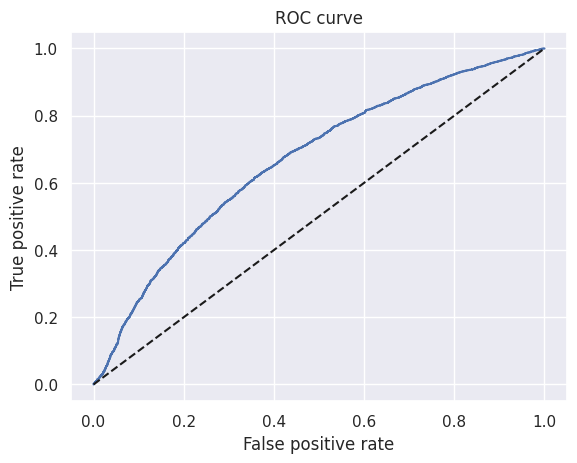

In [268]:
plt.plot(fpr, tpr)
# Wir zeichnen die Falsch-Positiv-Rate entlang
# der x-Achse und die Echt-Positiv-Rate entlang der y-Achse
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
# Wir zeichnen eine zweite diagonale Linie mit
# gestricheltem Linienstil und schwarzer Farbe.
plt.xlabel('False positive rate')
# Wir benennen die x-Achse „Falsch-positiv-Rate”.
plt.ylabel('True positive rate')
# Wir benennen die x-axis "True positive rate".
plt.title('ROC curve')
# "ROC curve".

### Interpretation der ROC-Kurve und des AUROC-Wertes für LGD-Stufe 1

Nachdem wir die Modellleistung anhand der Konfusionsmatrix bewertet haben, wenden wir uns der Receiver Operating Characteristic (ROC)-Kurve und der Area Under the Receiver Operating Characteristic (AUROC)-Fläche zu. Diese Metriken sind besonders nützlich, um die Fähigkeit eines Klassifikationsmodells zu beurteilen, positive und negative Klassen über verschiedene Klassifikationsschwellen hinweg zu unterscheiden.

**Was ist die ROC-Kurve?**

Die ROC-Kurve ist eine grafische Darstellung der Klassifikationsleistung eines binären Klassifikators, wenn seine Diskriminierungsschwelle variiert wird. Sie wird gezeichnet, indem die True Positive Rate (TPR) – auch bekannt als Recall oder Sensitivität – gegen die False Positive Rate (FPR) aufgetragen wird.

*   **True Positive Rate (TPR):** Der Anteil der tatsächlich positiven Fälle, die korrekt als positiv identifiziert wurden. (TP / (TP + FN))
*   **False Positive Rate (FPR):** Der Anteil der tatsächlich negativen Fälle, die fälschlicherweise als positiv identifiziert wurden. (FP / (FP + TN))

Eine ideale ROC-Kurve verläuft entlang der oberen linken Ecke des Diagramms, was bedeutet, dass das Modell eine hohe TPR bei gleichzeitig niedriger FPR erreicht. Die diagonale Linie (gestrichelt) repräsentiert ein zufälliges Modell (keine Diskriminierungsfähigkeit).

**Interpretation des AUROC-Wertes:**

Der AUROC-Wert (Area Under the Receiver Operating Characteristic Curve) ist eine einzelne Zusammenfassungsstatistik für die ROC-Kurve. Er gibt die Wahrscheinlichkeit an, dass das Modell einen zufällig ausgewählten positiven Fall höher bewertet als einen zufällig ausgewählten negativen Fall.

*   **AUROC = 1:** Perfektes Modell, das positive und negative Fälle vollständig trennen kann.
*   **AUROC = 0.5:** Zufälliges Modell (nicht besser als das Raten).
*   **AUROC < 0.5:** Schlechter als ein zufälliges Modell (das Modell klassifiziert tendenziell falsch).

**Ergebnisse unseres Modells:**

Für unser LGD-Modell der Stufe 1 wurde ein AUROC-Wert von **0.6684** (gerundet 0.668) berechnet.

**Bedeutung des AUROC-Wertes von 0.668:**

Ein AUROC-Wert von 0.668 deutet darauf hin, dass unser Modell eine **moderate** Diskriminierungsfähigkeit besitzt. Das bedeutet, dass es besser ist als ein zufälliges Modell (0.5), aber noch Raum für Verbesserungen besteht, um die Fähigkeit zu erhöhen, zwischen Krediten mit positiver Rückgewinnung und Krediten ohne Rückgewinnung zu unterscheiden. Im Kreditrisikomanagement strebt man typischerweise höhere AUROC-Werte an, oft über 0.7 oder sogar 0.8, um eine robuste Vorhersagequalität zu gewährleisten.

Zusammenfassend lässt sich sagen, dass die ROC-Kurve und der AUROC-Wert die Fähigkeit des Modells zur Unterscheidung zwischen den beiden Klassen visuell und quantitativ bestätigen. Unser aktuelles Modell ist dazu in der Lage, ist aber nicht perfekt und könnte durch weitere Feature Engineering, Modelloptimierung oder die Auswahl anderer Modellalgorithmen potenziell verbessert werden.

In [269]:
AUROC = roc_auc_score(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_proba_lgd_stage_1'])
# Berechnet die Fläche unter der Empfänger-Operationscharakteristik-Kurve (AUROC)
# aus einer Reihe von tatsächlichen Werten und deren vorhergesagten Wahrscheinlichkeiten.
AUROC

np.float64(0.6684499627117634)

In [270]:
import pickle

In [271]:
pickle.dump(reg_lgd_st_1, open('lgd_model_stage_1.sav', 'wb'))
# Hier exportieren wir unser Modell in eine „SAV”-Datei
# mit dem Dateinamen „lgd_model_stage_1.sav”.

### Stage 2 – Linear Regression

In [272]:
lgd_stage_2_data = loan_data_defaults[loan_data_defaults['recovery_rate_0_1'] == 1]
# Hier nehmen wir nur Zeilen, in denen die ursprüngliche Wiederherstellungsrate größer als eins ist,
# d. h. in denen die von uns erstellte Indikatorvariable gleich 1 ist.

In [273]:
# LGD-Modell Stufe 2 Datensätze: Wie viel mehr als 0 beträgt die Rückzahlungsquote?
lgd_inputs_stage_2_train, lgd_inputs_stage_2_test, lgd_targets_stage_2_train, lgd_targets_stage_2_test = train_test_split(lgd_stage_2_data.drop(['good_bad', 'recovery_rate','recovery_rate_0_1', 'CCF'], axis = 1), lgd_stage_2_data['recovery_rate'], test_size = 0.2, random_state = 42)
# Nimmt eine Reihe von Eingaben und eine Reihe von Zielen als Argumente entgegen. Teilt die Eingaben und Ziele in vier Datenrahmen auf:
# Eingaben – Training, Eingaben – Test, Ziele – Training, Ziele – Test.

In [293]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

mse_lgd_stage_2 = mean_squared_error(lgd_targets_stage_2_test, y_hat_test_lgd_stage_2)
r2_lgd_stage_2 = r2_score(lgd_targets_stage_2_test, y_hat_test_lgd_stage_2)

print(f"Mean Squared Error (MSE) for LGD Stage 2: {mse_lgd_stage_2:.4f}")
print(f"R-squared (R2) for LGD Stage 2: {r2_lgd_stage_2:.4f}")

Mean Squared Error (MSE) for LGD Stage 2: 0.0079
R-squared (R2) for LGD Stage 2: 0.0947


In [285]:
import scipy.stats as stat

# Da wir eine objektorientierte Sprache wie Python verwenden, können wir einfach unsere eigene
# LinearRegression-Klasse definieren (die gleiche wie in sklearn)
# Durch Eingabe des folgenden Codes überschreiben wir einen Teil der Klasse mit einem, der p-Werte enthält.
# Hier ist der vollständige Quellcode der ORIGINAL-Klasse: https://github.com/scikit-learn/scikit-learn/blob/7b136e9/sklearn/linear_model/base.py#L362


class LinearRegression(linear_model.LinearRegression):
    """
     LinearRegression-Klasse nach sklearn, berechnet jedoch t-Statistiken
    und p-Werte für Modellkoeffizienten (Betas).
    Zusätzliche Attribute, die nach .fit() verfügbar sind,
    sind `t` und `p`, die die Form (y.shape[1], X.shape[1]) haben,
    also (n_features, n_coefs).
    Diese Klasse setzt den Schnittpunkt standardmäßig auf 0, da wir ihn normalerweise
    in X einbeziehen.
    """

    # nothing changes in __init__
    def __init__(self, fit_intercept=True, copy_X=True,
                 n_jobs=1):
        super().__init__(fit_intercept=fit_intercept, copy_X=copy_X, n_jobs=n_jobs)


    def fit(self, X, y, n_jobs=1):
        # Rufe die ursprüngliche fit-Methode aus der übergeordneten Klasse auf.
        super().fit(X, y, n_jobs)

        # Berechne SSE (Summe der quadrierten Fehler)
        # und SE (Standardfehler)
        sse = np.sum((self.predict(X) - y) ** 2, axis=0) / float(X.shape[0] - X.shape[1])
        se = np.array([np.sqrt(np.diagonal(sse * np.linalg.inv(np.dot(X.T, X))))])

        # Berechne die t-Statistik für jedes Merkmal.
        self.t = self.coef_ / se
        # Finden Sie den p-Wert für jedes Merkmal.
        self.p = np.squeeze(2 * (1 - stat.t.cdf(np.abs(self.t), y.shape[0] - X.shape[1])))
        return self

In [290]:
lgd_inputs_stage_2_test = lgd_inputs_stage_2_test[features_all]
# Hier behalten wir nur die Variablen, die wir für das Modell benötigen.

In [291]:
lgd_inputs_stage_2_test = lgd_inputs_stage_2_test.drop(features_reference_cat, axis = 1)
# Hier entfernen wir die Referenzkategorien der Dummy-Variablen.

In [292]:
reg_lgd_st_2 = LinearRegression()
# Wir erstellen eine Instanz eines Objekts aus der Klasse „LinearRegression”.
reg_lgd_st_2.fit(lgd_inputs_stage_2_train, lgd_targets_stage_2_train)

y_hat_test_lgd_stage_2 = reg_lgd_st_2.predict(lgd_inputs_stage_2_test)
# Wir erstellen Vorhersagen für den Testdatensatz.

y_hat_test_lgd_stage_2 = np.maximum(0, y_hat_test_lgd_stage_2)
# Wir setzen das Minimum der vorhergesagten Werte auf 0.

y_hat_test_lgd_stage_2 = np.minimum(1, y_hat_test_lgd_stage_2)
# Wir setzen das Maximum der vorhergesagten Werte auf 1.


In [287]:
feature_name = lgd_inputs_stage_2_train.columns.values
# Speichert die Namen der Spalten eines Datenrahmens in einer Variablen.

In [288]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
# Erstellt einen Datenrahmen mit
# einer Spalte namens „Feature name” und Zeilenwerten,
# die in der Variablen „feature_name” enthalten sind.
summary_table['Coefficients'] = np.transpose(reg_lgd_st_2.coef_)
# Erstellt eine neue Spalte im Datenrahmen mit dem Namen „Koeffizienten”
# mit Zeilenwerten, die die transponierten Koeffizienten aus dem Objekt
summary_table.index = summary_table.index + 1
# Erhöht den Index jeder Zeile des Datenrahmens um 1.
summary_table.loc[0] = ['Intercept', reg_lgd_st_2.intercept_]
# Weist Werte der Zeile mit Index 0 des Datenrahmens zu.
summary_table = summary_table.sort_index()
# Sortiert den Datenrahmen nach Index.
p_values = reg_lgd_st_2.p
# Wir nehmen das Ergebnis der neu hinzugefügten
# Methode „p_values” und speichern es in einer Variablen „p_values
p_values = np.append(np.nan,np.array(p_values))
# Wir fügen den Wert „NaN” am Anfang der Variablen mit p-Werten hinzu.
summary_table['p_values'] = p_values.round(3)
# Im Datenrahmen „summary_table” fügen wir eine neue
# Spalte namens „p_values” hinzu, die die Werte aus der Variablen „p_values” enthält.
summary_table

,Feature name,Coefficients,p_values
0,Intercept,2.406858e-01,NaN
1,grade:A,-6.826892e-02,0.000
2,grade:B,-5.083556e-02,0.000
3,grade:C,-3.748066e-02,0.000
4,grade:D,-2.717310e-02,0.000
5,grade:E,-1.315941e-02,0.002
6,grade:F,-5.260168e-03,0.275
7,home_ownership:MORTGAGE,2.832212e-03,0.061
8,home_ownership:NONE,1.459035e-01,0.000
9,home_ownership:OTHER,-9.475922e-03,0.644


Diese Tabelle zeigt die geschätzten Koeffizienten und die zugehörigen p-Werte für jedes Merkmal (Feature) in unserem linearen Regressionsmodell. Diese Werte helfen uns zu verstehen, welche Faktoren die Höhe der Rückgewinnungsquote (Recovery Rate) beeinflussen, wenn eine Rückgewinnung stattfindet.

**Generelle Interpretation:**

*   **Koeffizienten:** Der Wert eines Koeffizienten gibt an, wie sich die vorhergesagte Recovery Rate ändert, wenn sich das entsprechende Merkmal um eine Einheit ändert, während alle anderen Merkmale konstant gehalten werden.
    *   Ein **positiver Koeffizient** bedeutet, dass ein Anstieg des Merkmals zu einer *höheren* Recovery Rate führt.
    *   Ein **negativer Koeffizient** bedeutet, dass ein Anstieg des Merkmals zu einer *niedrigeren* Recovery Rate führt.
*   **p-Werte:** Der p-Wert gibt die Wahrscheinlichkeit an, dass der beobachtete Effekt (oder ein extremerer Effekt) auftritt, wenn es tatsächlich keinen Zusammenhang zwischen dem Merkmal und der Recovery Rate gäbe. Ein kleiner p-Wert (üblicherweise < 0.05 oder < 0.01) zeigt an, dass das Merkmal statistisch signifikant ist und sein Einfluss auf die Recovery Rate wahrscheinlich nicht zufällig ist.

**Detaillierte Bewertung der Ergebnisse:**

1.  **Intercept (Konstante):**
    *   **Koeffizient:** 0.2406858 (ca. 24.07%)
    *   **p-Wert:** NaN (nicht zutreffend für den Intercept)
    *   **Interpretation:** Dies ist der erwartete Recovery Rate, wenn alle anderen Features den Wert Null haben. Es repräsentiert einen Basissatz der Recovery Rate.

2.  **Grade der Kredite (grade:A bis grade:F):**
    *   **Koeffizienten (relativ zu grade:G):**
        *   `grade:A`: -0.068 (sehr signifikant, p=0.000)
        *   `grade:B`: -0.051 (sehr signifikant, p=0.000)
        *   `grade:C`: -0.037 (sehr signifikant, p=0.000)
        *   `grade:D`: -0.027 (sehr signifikant, p=0.000)
        *   `grade:E`: -0.013 (signifikant, p=0.002)
        *   `grade:F`: -0.005 (nicht signifikant, p=0.275)
    *   **Interpretation:** Es ist auffällig, dass alle besseren Kredit-Grades (A-E) negative Koeffizienten haben, was bedeutet, dass sie, relativ zur Referenzkategorie G, mit einer *niedrigeren* Recovery Rate verbunden sind. Dies ist eine **kontraintuitive** Beobachtung. Normalerweise würde man erwarten, dass bessere Grades (geringeres Risiko) zu höheren Recovery Rates führen. Dies könnte auf mehrere Faktoren hindeuten:
        *   **Referenzkategorie:** Die Wahl von `grade:G` als Referenz könnte die Interpretation verzerren, da G die schlechteste Kreditqualität darstellt. Es könnte sinnvoller sein, eine bessere Kategorie als Referenz zu wählen oder alle Grades als einzelne Variablen zu behandeln.
        *   **Datencharakteristik:** Es könnte sein, dass bei den ausgefallenen Krediten (für die dieses Modell gilt), die Mechanismen der Rückgewinnung bei besseren Grades anders funktionieren. Es ist auch möglich, dass die Recovery Rate für G-Kredite in diesem Datensatz aus bestimmten Gründen höher war, oder dass das Modell die Komplexität dieser Beziehung nicht vollständig erfasst.
        *   **Fehler in der Datenvorbereitung:** Eine Überprüfung der Dummy-Kodierung und des Datensatzes wäre ratsam.

3.  **Home Ownership (home_ownership):**
    *   `home_ownership:MORTGAGE`: 0.003 (signifikant, p=0.061)
    *   `home_ownership:NONE`: 0.146 (sehr signifikant, p=0.000) – **sehr hoher positiver Effekt**
    *   `home_ownership:OTHER`: -0.009 (nicht signifikant, p=0.644)
    *   `home_ownership:OWN`: 0.005 (signifikant, p=0.040)
    *   **Interpretation:** `home_ownership:NONE` hat einen sehr starken positiven Effekt auf die Recovery Rate. Dies ist ebenfalls ungewöhnlich, da man erwarten würde, dass Immobilienbesitz eher zu besseren Sicherheiten und damit zu höheren Rückgewinnungen führt. Das deutet auf eine Besonderheit in den Daten hin, die genauer untersucht werden sollte. MORTGAGE und OWN haben einen kleinen positiven, aber signifikanten Effekt, was eher den Erwartungen entspricht.

4.  **Purpose des Kredits (purpose):**
    *   `purpose:educational`: 0.076 (sehr signifikant, p=0.000) – **starker positiver Effekt**
    *   `purpose:wedding`: 0.020 (signifikant, p=0.006)
    *   `purpose:moving`: 0.014 (signifikant, p=0.039)
    *   Andere Zwecke wie `car`, `debt_consolidation`, `home_improvement`, `house`, `major_purchase`, `medical`, `other`, `renewable_energy`, `small_business`, `vacation` sind größtenteils **nicht signifikant** oder zeigen sehr kleine Effekte.
    *   **Interpretation:** Kredite für Bildung und Hochzeiten scheinen eine signifikant höhere Recovery Rate zu haben. Das könnte darauf hindeuten, dass bei diesen Kreditnehmern die Motivation zur Rückzahlung (auch nach einem Ausfall) oder die Fähigkeit zur Rückgewinnung durch Dritte (z.B. Familie) höher ist.

5.  **Initial List Status (initial_list_status:w):**
    *   **Koeffizient:** 0.015 (sehr signifikant, p=0.000)
    *   **Interpretation:** Ein Kredit, der mit dem Initial List Status 'w' gelistet wurde (im Gegensatz zu 'f' als Referenz), führt zu einer höheren Recovery Rate. Dies könnte auf unterschiedliche Prozesse oder Risikoprofile hinter diesen Listungsstatus hindeuten.

6.  **Kreditlaufzeit (term_int):**
    *   **Koeffizient:** 0.00033 (signifikant, p=0.020)
    *   **Interpretation:** Ein geringer positiver Effekt; längere Kreditlaufzeiten sind leicht mit einer höheren Recovery Rate verbunden, was auf den ersten Blick unerwartet ist, da längere Laufzeiten oft höheres Risiko bedeuten.

7.  **Monate seit Kreditvergabe (mths_since_issue_d) und erste Kreditlinie (mths_since_earliest_cr_line):**
    *   `mths_since_issue_d`: -0.0015 (sehr signifikant, p=0.000) – ältere Kredite (mehr Monate seit Vergabe) haben eine niedrigere RR.
    *   `mths_since_earliest_cr_line`: 0.000034 (sehr signifikant, p=0.000) – eine längere Kredithistorie (frühere erste Kreditlinie) hat eine höhere RR.
    *   **Interpretation:** Diese Ergebnisse sind plausibel: Aktuellere Kredite neigen zu höheren Rückgewinnungen, während Kunden mit einer längeren allgemeinen Kredithistorie (was auf Erfahrung und Zuverlässigkeit hindeuten kann) ebenfalls bessere Rückgewinnungsquoten aufweisen.

8.  **Zinssatz (int_rate):**
    *   **Koeffizient:** -0.0025 (sehr signifikant, p=0.000)
    *   **Interpretation:** Höhere Zinssätze führen zu niedrigeren Recovery Rates, was oft mit einem höheren Kreditrisiko verbunden ist.

9.  **Jahreseinkommen (annual_inc):**
    *   **Koeffizient:** 6.389841e-08 (sehr klein, aber signifikant, p=0.001)
    *   **Interpretation:** Ein höheres Jahreseinkommen ist mit einer minimal höheren Recovery Rate verbunden, was intuitiv ist.

10. **Anzahl der offenen Kreditlinien (open_acc) & Gesamtzahl der Konten (total_acc):**
    *   `open_acc`: -0.0012 (sehr signifikant, p=0.000) – mehr offene Konten führen zu niedrigerer RR.
    *   `total_acc`: 0.00048 (sehr signifikant, p=0.000) – mehr Gesamtkonten führen zu höherer RR.
    *   **Interpretation:** Hier gibt es einen widersprüchlichen Effekt, der auf eine Multikollinearität oder komplexe Interaktion hindeuten könnte. Mehr *offene* Konten scheinen schlecht für die RR zu sein, während eine höhere *Gesamtzahl* an Konten (auch geschlossene) gut zu sein scheint. Dies sollte genauer untersucht werden.

11. **Gesamte hohe Revolving-Kreditlinie (total_rev_hi_lim):**
    *   **Koeffizient:** 2.263456e-07 (sehr klein, aber signifikant, p=0.000)
    *   **Interpretation:** Eine höhere verfügbare Kreditlinie ist mit einer minimal höheren Recovery Rate verbunden.

**Fazit zur Tabelle:**

Die Tabelle liefert interessante Einblicke in die Faktoren, die die Recovery Rate beeinflussen. Einige Ergebnisse sind intuitiv und passen zu den Erwartungen an das Kreditrisikomanagement (z.B. der Einfluss von `int_rate`, `mths_since_issue_d`, `mths_since_earliest_cr_line`). Andere Ergebnisse, insbesondere die negativen Koeffizienten für die Kredit-Grades A-E und der hohe positive Effekt von `home_ownership:NONE`, sind **unerwartet und bedürfen weiterer Untersuchung**. Dies könnte auf spezifische Merkmale des Datensatzes, die Wahl der Referenzkategorien oder komplexere Beziehungen hindeuten, die ein lineares Modell nicht vollständig erfasst.

Für die weitere Arbeit würde ich empfehlen, diese unerwarteten Beziehungen genauer zu untersuchen, eventuell Interaktionsterme zu testen oder andere Modellierungsansätze in Betracht zu ziehen, die nicht-lineare Beziehungen besser abbilden können. Es ist auch wichtig, die Geschäftslogik hinter den Beobachtungen zu verstehen, um das Modell im Kontext des Kreditrisikomanagements validieren zu können.